# Gestion des horraires des employées

In [4]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os 

extract_path = "../Source/in_time.csv"
data_in_time = pd.read_csv(extract_path)

# Renommer la colonne sans nom par EmployeeID
data_in_time = data_in_time.rename(columns={data_in_time.columns[0]: 'EmployeeID'})

data_in_time.head()

,EmployeeID,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31,2015-01-08 09:51:09,2015-01-09 10:09:25,2015-01-12 09:42:53,2015-01-13 10:13:06,...,NaN,2015-12-21 09:55:29,2015-12-22 10:04:06,2015-12-23 10:14:27,2015-12-24 10:11:35,NaN,2015-12-28 10:13:41,2015-12-29 10:03:36,2015-12-30 09:54:12,2015-12-31 10:12:44
1,2,NaN,2015-01-02 10:15:44,2015-01-05 10:21:05,NaN,2015-01-07 09:45:17,2015-01-08 10:09:04,2015-01-09 09:43:26,2015-01-12 10:00:07,2015-01-13 10:43:29,...,2015-12-18 10:37:17,2015-12-21 09:49:02,2015-12-22 10:33:51,2015-12-23 10:12:10,NaN,NaN,2015-12-28 09:31:45,2015-12-29 09:55:49,2015-12-30 10:32:25,2015-12-31 09:27:20
2,3,NaN,2015-01-02 10:17:41,2015-01-05 09:50:50,2015-01-06 10:14:13,2015-01-07 09:47:27,2015-01-08 10:03:40,2015-01-09 10:05:49,2015-01-12 10:03:47,2015-01-13 10:21:26,...,2015-12-18 10:15:14,2015-12-21 10:10:28,2015-12-22 09:44:44,2015-12-23 10:15:54,2015-12-24 10:07:26,NaN,2015-12-28 09:42:05,2015-12-29 09:43:36,2015-12-30 09:34:05,2015-12-31 10:28:39
3,4,NaN,2015-01-02 10:05:06,2015-01-05 09:56:32,2015-01-06 10:11:07,2015-01-07 09:37:30,2015-01-08 10:02:08,2015-01-09 10:08:12,2015-01-12 10:13:42,2015-01-13 09:53:22,...,2015-12-18 10:17:38,2015-12-21 09:58:21,2015-12-22 10:04:25,2015-12-23 10:11:46,2015-12-24 09:43:15,NaN,2015-12-28 09:52:44,2015-12-29 09:33:16,2015-12-30 10:18:12,2015-12-31 10:01:15
4,5,NaN,2015-01-02 10:28:17,2015-01-05 09:49:58,2015-01-06 09:45:28,2015-01-07 09:49:37,2015-01-08 10:19:44,2015-01-09 10:00:50,2015-01-12 10:29:27,2015-01-13 09:59:32,...,2015-12-18 09:58:35,2015-12-21 10:03:41,2015-12-22 10:10:30,2015-12-23 10:13:36,2015-12-24 09:44:24,NaN,2015-12-28 10:05:15,2015-12-29 10:30:53,2015-12-30 09:18:21,2015-12-31 09:41:09



ANALYSE DES DATES DANS LES NOMS DE COLONNES

1. EXTRACTION DES DATES:
   Dimensions: (4410, 262)
   Colonnes (premières): ['EmployeeID', '2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06']
   ✓ 261 dates détectées et analysées

2. TOP 20 DATES AVEC LE PLUS DE NaN:
--------------------------------------------------------------------------------
   ⚪ 2015-01-01 (Thu) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-01-14 (Wed) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-11 (Wed) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-10 (Tue) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-09 (Mon) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-05-01 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-12-25 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-01-26 (Mon) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-03-05 (Thu) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-10-02 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-07-17 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-09-17 (Thu) | NaN: 4410/4410 | Rat

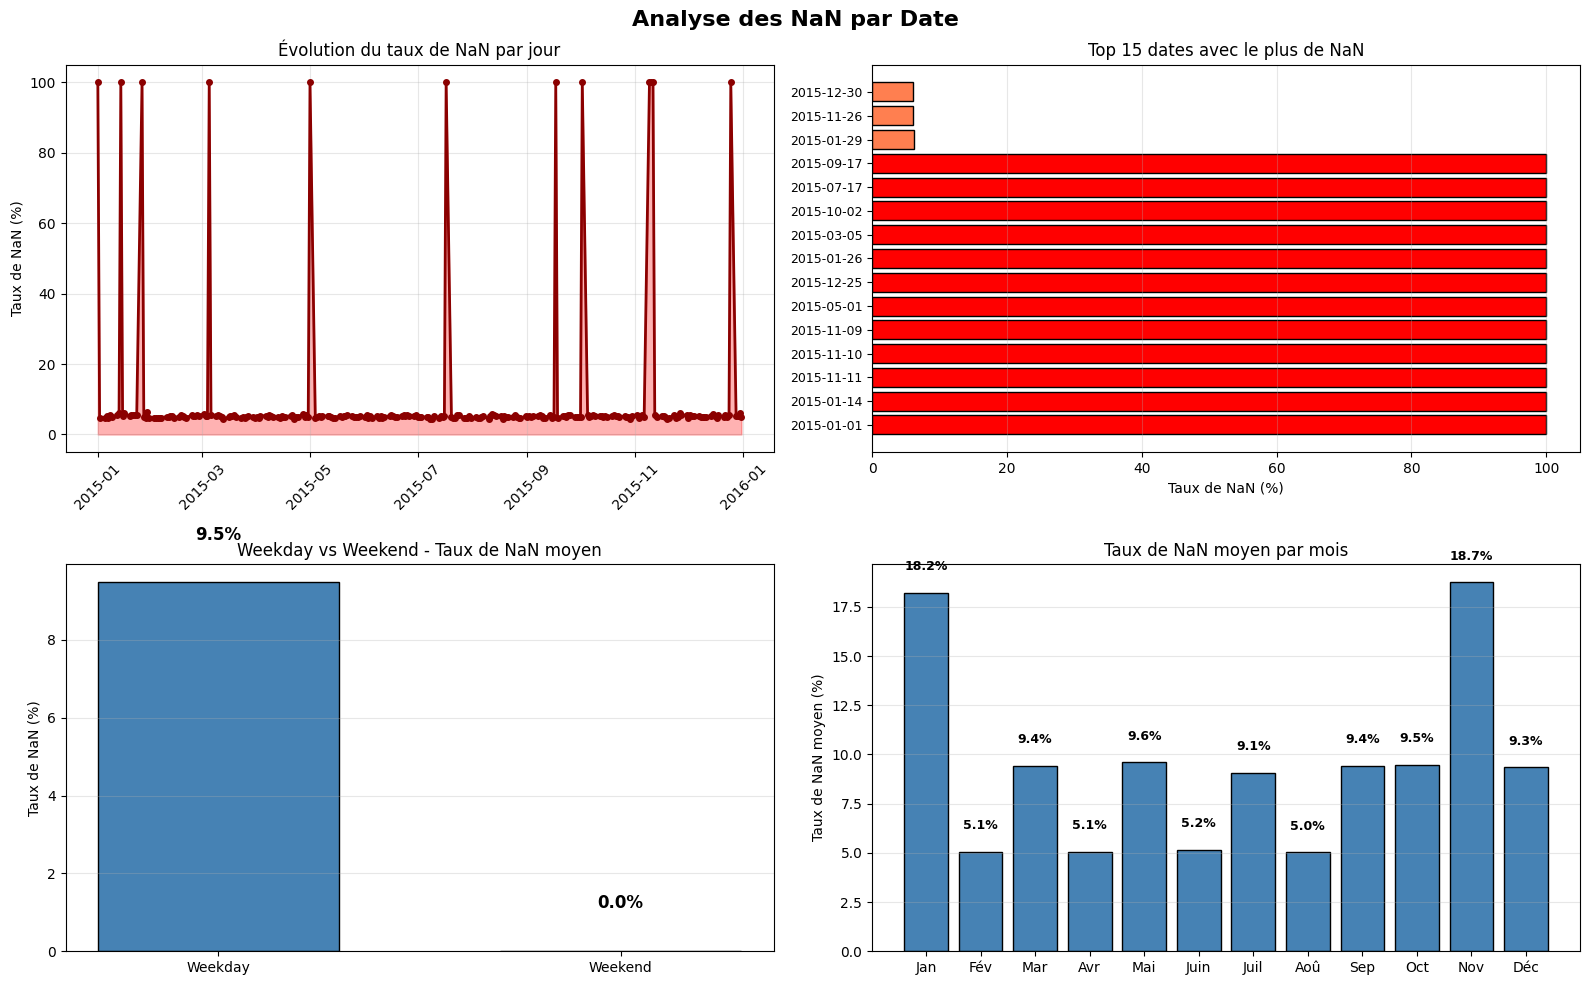


✓ Analyse complétée!


In [5]:
print("\n" + "=" * 80)
print("ANALYSE DES DATES DANS LES NOMS DE COLONNES")
print("=" * 80)

# 1. EXTRAIRE LES DATES DES NOMS DE COLONNES
print("\n1. EXTRACTION DES DATES:")
print(f"   Dimensions: {data_in_time.shape}")
print(f"   Colonnes (premières): {list(data_in_time.columns[:5])}")

# Récupérer toutes les colonnes sauf la première (EmployeeID)
date_columns = data_in_time.columns[1:]

# Convertir les noms de colonnes en dates
dates = []
for col in date_columns:
    try:
        date = pd.to_datetime(col, errors='coerce')
        dates.append(date)
    except:
        dates.append(None)

# Créer un dataframe avec les stats
daily_stats = []

for col, date in zip(date_columns, dates):
    if date is not None and pd.notna(date):
        nan_count = data_in_time[col].isnull().sum()
        total_values = len(data_in_time)
        nan_rate = (nan_count / total_values * 100) if total_values > 0 else 0
        day_name = date.day_name()
        is_weekend = date.dayofweek >= 5
        month = date.month
        
        daily_stats.append({
            'Date': date,
            'DayName': day_name,
            'IsWeekend': is_weekend,
            'Month': month,
            'NaN_Count': nan_count,
            'Total_Values': total_values,
            'NaN_Rate_%': nan_rate
        })

daily_df = pd.DataFrame(daily_stats)
daily_df = daily_df.sort_values('NaN_Rate_%', ascending=False)

print(f"   ✓ {len(daily_df)} dates détectées et analysées")

# 2. TOP 20 DATES AVEC LE PLUS DE NaN
print("\n2. TOP 20 DATES AVEC LE PLUS DE NaN:")
print("-" * 80)

for idx, row in daily_df.head(20).iterrows():
    marker = "🔴" if row['IsWeekend'] else "⚪"
    print(f"   {marker} {row['Date'].strftime('%Y-%m-%d')} ({row['DayName'][:3]}) | "
          f"NaN: {int(row['NaN_Count'])}/{int(row['Total_Values'])} | "
          f"Rate: {row['NaN_Rate_%']:.2f}%")

# 3. JOURS AVEC 100% DE NaN
print("\n3. JOURS AVEC 100% DE NaN:")
full_nan_dates = daily_df[daily_df['NaN_Rate_%'] >= 99.5]
print(f"   Nombre: {len(full_nan_dates)}")

if len(full_nan_dates) > 0:
    for idx, row in full_nan_dates.iterrows():
        marker = "🔴 WEEKEND" if row['IsWeekend'] else "🔴 WEEKDAY"
        print(f"   {marker} | {row['Date'].strftime('%Y-%m-%d')} ({row['DayName']})")

# 4. STATISTIQUES GLOBALES
print("\n4. STATISTIQUES GLOBALES:")

weekday_df = daily_df[daily_df['IsWeekend'] == False]
weekend_df = daily_df[daily_df['IsWeekend'] == True]

weekday_avg = weekday_df['NaN_Rate_%'].mean() if len(weekday_df) > 0 else 0
weekend_avg = weekend_df['NaN_Rate_%'].mean() if len(weekend_df) > 0 else 0

print(f"\n   WEEKDAY (Lun-Ven):")
print(f"      • Nombre de jours: {len(weekday_df)}")
print(f"      • Taux NaN moyen: {weekday_avg:.2f}%")
print(f"      • Taux NaN min-max: {weekday_df['NaN_Rate_%'].min():.2f}% - {weekday_df['NaN_Rate_%'].max():.2f}%")

print(f"\n   WEEKEND (Sam-Dim):")
print(f"      • Nombre de jours: {len(weekend_df)}")
print(f"      • Taux NaN moyen: {weekend_avg:.2f}%")
print(f"      • Taux NaN min-max: {weekend_df['NaN_Rate_%'].min():.2f}% - {weekend_df['NaN_Rate_%'].max():.2f}%")

# 5. ANALYSE PAR MOIS
print("\n5. ANALYSE PAR MOIS:")
monthly_stats = daily_df.groupby('Month').agg({
    'NaN_Rate_%': 'mean',
    'Date': 'count'
}).rename(columns={'Date': 'Nb_Days'})

months = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin', 
          'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

for month_num, row in monthly_stats.iterrows():
    month_name = months[int(month_num)-1]
    print(f"   {month_name}: {int(row['Nb_Days'])} jours, {row['NaN_Rate_%']:.2f}% NaN moyen")

# 6. VISUALISATION
print("\n6. CRÉATION DES VISUALISATIONS:")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analyse des NaN par Date', fontsize=16, fontweight='bold')

# Graphique 1: Évolution temporelle
ax = axes[0, 0]
daily_df_sorted = daily_df.sort_values('Date')
ax.plot(daily_df_sorted['Date'], daily_df_sorted['NaN_Rate_%'], 
        marker='o', linestyle='-', color='darkred', linewidth=2, markersize=4)
ax.fill_between(daily_df_sorted['Date'], daily_df_sorted['NaN_Rate_%'], alpha=0.3, color='red')
ax.set_title('Évolution du taux de NaN par jour')
ax.set_ylabel('Taux de NaN (%)')
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Graphique 2: Top 15 dates
ax = axes[0, 1]
top_15 = daily_df.head(15)
colors_bar = ['red' if x >= 99 else 'orange' if x >= 80 else 'coral' 
              for x in top_15['NaN_Rate_%']]
bars = ax.barh(range(len(top_15)), top_15['NaN_Rate_%'], color=colors_bar, edgecolor='black')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels([d.strftime('%Y-%m-%d') for d in top_15['Date']], fontsize=9)
ax.set_xlabel('Taux de NaN (%)')
ax.set_title('Top 15 dates avec le plus de NaN')
ax.grid(alpha=0.3, axis='x')

# Graphique 3: Weekday vs Weekend
ax = axes[1, 0]
categories = ['Weekday', 'Weekend']
rates = [weekday_avg, weekend_avg]
colors = ['steelblue', 'orange']
bars = ax.bar(categories, rates, color=colors, edgecolor='black', width=0.6)
ax.set_ylabel('Taux de NaN (%)')
ax.set_title('Weekday vs Weekend - Taux de NaN moyen')
ax.grid(alpha=0.3, axis='y')

for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=12)

# Graphique 4: Distribution par mois
ax = axes[1, 1]
month_names_short = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 
                     'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
month_labels_plot = [month_names_short[m-1] for m in monthly_stats.index]

bars = ax.bar(month_labels_plot, monthly_stats['NaN_Rate_%'], 
              color='steelblue', edgecolor='black')
ax.set_ylabel('Taux de NaN moyen (%)')
ax.set_title('Taux de NaN moyen par mois')
ax.grid(alpha=0.3, axis='y')

for bar, val in zip(bars, monthly_stats['NaN_Rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Analyse complétée!")
print("=" * 80)

In [6]:
print("\n" + "=" * 80)
print("ANALYSE SIMPLE: JOURS AVEC 100% NaN - WEEKENDS OU JOURS FÉRIÉS?")
print("=" * 80)

# 1. Définir les jours fériés indiens 2015
indian_holidays_2015 = {
    '2015-01-01': 'New Year Day',
    '2015-01-26': 'Republic Day',
    '2015-03-06': 'Maha Shivaratri',
    '2015-03-17': 'Holi',
    '2015-04-02': 'Ram Navami',
    '2015-04-10': 'Good Friday',
    '2015-04-21': 'Mahavir Jayanti',
    '2015-05-01': 'May Day',
    '2015-05-25': 'Buddha Pournima',
    '2015-08-15': 'Independence Day',
    '2015-08-29': 'Janmashtami',
    '2015-09-02': 'Ganesh Chaturthi',
    '2015-10-02': 'Gandhi Jayanti',
    '2015-10-16': 'Dussehra',
    '2015-10-28': 'Diwali',
    '2015-11-25': 'Guru Nanak Jayanti',
    '2015-12-25': 'Christmas'
}

holidays_dates = [pd.to_datetime(date) for date in indian_holidays_2015.keys()]

# 2. Ajouter colonne holiday à daily_df
daily_df['Is_Holiday'] = daily_df['Date'].isin(holidays_dates)

# 3. Trouver les jours avec 100% NaN
full_nan_days = daily_df[daily_df['NaN_Rate_%'] >= 99.5].copy()

print(f"\nJOURS AVEC 100% DE NaN: {len(full_nan_days)} jours")
print("-" * 80)

# Compter les types
weekends_100 = full_nan_days[full_nan_days['IsWeekend'] == True]
weekdays_100 = full_nan_days[full_nan_days['IsWeekend'] == False]

holidays_100 = full_nan_days[full_nan_days['Is_Holiday'] == True]
ordinary_100 = full_nan_days[full_nan_days['Is_Holiday'] == False]

print(f"\n1. PAR TYPE DE JOUR:")
print(f"   • WEEKENDS (Samedi-Dimanche): {len(weekends_100)}")
print(f"   • WEEKDAYS (Lun-Ven): {len(weekdays_100)}")

print(f"\n2. PAR CATÉGORIE:")
print(f"   • Jours Fériés Indiens: {len(holidays_100)}")
print(f"   • Jours Ordinaires: {len(ordinary_100)}")

print(f"\n3. DÉTAIL DES JOURS AVEC 100% NaN:")
print("-" * 80)

for idx, row in full_nan_days.iterrows():
    is_holiday_marker = "🎉" if row['Is_Holiday'] else ""
    is_weekend_marker = "🔴 WEEKEND" if row['IsWeekend'] else "⚪ WEEKDAY"
    
    holiday_name = ""
    if row['Is_Holiday']:
        for hol_date, hol_name in indian_holidays_2015.items():
            if pd.to_datetime(hol_date) == row['Date']:
                holiday_name = f" | {hol_name}"
                break
    
    print(f"{is_weekend_marker} {is_holiday_marker} | {row['Date'].strftime('%Y-%m-%d')} ({row['DayName']}) {holiday_name}")

# 4. Statistiques finales
print(f"\n4. RÉSUMÉ:")
print("-" * 80)
total_100 = len(full_nan_days)
weekend_pct = (len(weekends_100) / total_100 * 100) if total_100 > 0 else 0
holiday_pct = (len(holidays_100) / total_100 * 100) if total_100 > 0 else 0

print(f"   • % WEEKENDS parmi jours 100% NaN: {weekend_pct:.1f}% ({len(weekends_100)}/{total_100})")
print(f"   • % Jours Fériés parmi jours 100% NaN: {holiday_pct:.1f}% ({len(holidays_100)}/{total_100})")

# Cas spécial: Jours ordinaires ET weekdays (ni weekend ni fériés)
neither = full_nan_days[(full_nan_days['IsWeekend'] == False) & (full_nan_days['Is_Holiday'] == False)]
neither_pct = (len(neither) / total_100 * 100) if total_100 > 0 else 0
print(f"   • % Jours ordinaires de semaine (autres): {neither_pct:.1f}% ({len(neither)}/{total_100})")

print(f"\n✓ RÉPONSE: {'OUI - Presque tous sont des WEEKENDS' if weekend_pct > 80 else 'NON - Mélange de weekends et weekdays' if weekend_pct > 0 else 'NON - Aucun weekend'}")
print("=" * 80)


ANALYSE SIMPLE: JOURS AVEC 100% NaN - WEEKENDS OU JOURS FÉRIÉS?

JOURS AVEC 100% DE NaN: 12 jours
--------------------------------------------------------------------------------

1. PAR TYPE DE JOUR:
   • WEEKENDS (Samedi-Dimanche): 0
   • WEEKDAYS (Lun-Ven): 12

2. PAR CATÉGORIE:
   • Jours Fériés Indiens: 5
   • Jours Ordinaires: 7

3. DÉTAIL DES JOURS AVEC 100% NaN:
--------------------------------------------------------------------------------
⚪ WEEKDAY 🎉 | 2015-01-01 (Thursday)  | New Year Day
⚪ WEEKDAY  | 2015-01-14 (Wednesday) 
⚪ WEEKDAY  | 2015-11-11 (Wednesday) 
⚪ WEEKDAY  | 2015-11-10 (Tuesday) 
⚪ WEEKDAY  | 2015-11-09 (Monday) 
⚪ WEEKDAY 🎉 | 2015-05-01 (Friday)  | May Day
⚪ WEEKDAY 🎉 | 2015-12-25 (Friday)  | Christmas
⚪ WEEKDAY 🎉 | 2015-01-26 (Monday)  | Republic Day
⚪ WEEKDAY  | 2015-03-05 (Thursday) 
⚪ WEEKDAY 🎉 | 2015-10-02 (Friday)  | Gandhi Jayanti
⚪ WEEKDAY  | 2015-07-17 (Friday) 
⚪ WEEKDAY  | 2015-09-17 (Thursday) 

4. RÉSUMÉ:
--------------------------------------

In [7]:
extract_path = "../Source/out_time.csv"
data_out_time = pd.read_csv(extract_path)

# Renommer la colonne sans nom par EmployeeID
data_out_time = data_out_time.rename(columns={data_out_time.columns[0]: 'EmployeeID'})

data_out_time.head()

,EmployeeID,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 16:56:15,2015-01-05 17:20:11,2015-01-06 17:19:05,2015-01-07 16:34:55,2015-01-08 17:08:32,2015-01-09 17:38:29,2015-01-12 16:58:39,2015-01-13 18:02:58,...,NaN,2015-12-21 17:15:50,2015-12-22 17:27:51,2015-12-23 16:44:44,2015-12-24 17:47:22,NaN,2015-12-28 18:00:07,2015-12-29 17:22:30,2015-12-30 17:40:56,2015-12-31 17:17:33
1,2,NaN,2015-01-02 18:22:17,2015-01-05 17:48:22,NaN,2015-01-07 17:09:06,2015-01-08 17:34:04,2015-01-09 16:52:29,2015-01-12 17:36:48,2015-01-13 18:00:13,...,2015-12-18 18:31:28,2015-12-21 17:34:16,2015-12-22 18:16:35,2015-12-23 17:38:18,NaN,NaN,2015-12-28 17:08:38,2015-12-29 17:54:46,2015-12-30 18:31:35,2015-12-31 17:40:58
2,3,NaN,2015-01-02 16:59:14,2015-01-05 17:06:46,2015-01-06 16:38:32,2015-01-07 16:33:21,2015-01-08 17:24:22,2015-01-09 16:57:30,2015-01-12 17:28:54,2015-01-13 17:21:25,...,2015-12-18 17:02:23,2015-12-21 17:20:17,2015-12-22 16:32:50,2015-12-23 16:59:43,2015-12-24 16:58:25,NaN,2015-12-28 16:43:31,2015-12-29 17:09:56,2015-12-30 17:06:25,2015-12-31 17:15:50
3,4,NaN,2015-01-02 17:25:24,2015-01-05 17:14:03,2015-01-06 17:07:42,2015-01-07 16:32:40,2015-01-08 16:53:11,2015-01-09 17:19:47,2015-01-12 17:13:37,2015-01-13 17:11:45,...,2015-12-18 17:55:23,2015-12-21 16:49:09,2015-12-22 17:24:00,2015-12-23 17:36:35,2015-12-24 16:48:21,NaN,2015-12-28 17:19:34,2015-12-29 16:58:16,2015-12-30 17:40:11,2015-12-31 17:09:14
4,5,NaN,2015-01-02 18:31:37,2015-01-05 17:49:15,2015-01-06 17:26:25,2015-01-07 17:37:59,2015-01-08 17:59:28,2015-01-09 17:44:08,2015-01-12 18:51:21,2015-01-13 18:14:58,...,2015-12-18 17:52:48,2015-12-21 17:43:35,2015-12-22 18:07:57,2015-12-23 18:00:49,2015-12-24 17:59:22,NaN,2015-12-28 17:44:59,2015-12-29 18:47:00,2015-12-30 17:15:33,2015-12-31 17:42:14



ANALYSE DES DATES DANS LES NOMS DE COLONNES - OUT TIME

1. EXTRACTION DES DATES:
   Dimensions: (4410, 262)
   Colonnes (premières): ['EmployeeID', '2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06']
   ✓ 261 dates détectées et analysées

2. TOP 20 DATES AVEC LE PLUS DE NaN:
--------------------------------------------------------------------------------
   ⚪ 2015-01-01 (Thu) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-01-14 (Wed) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-11 (Wed) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-10 (Tue) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-11-09 (Mon) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-05-01 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-12-25 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-01-26 (Mon) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-03-05 (Thu) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-10-02 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-07-17 (Fri) | NaN: 4410/4410 | Rate: 100.00%
   ⚪ 2015-09-17 (Thu) | NaN: 4410

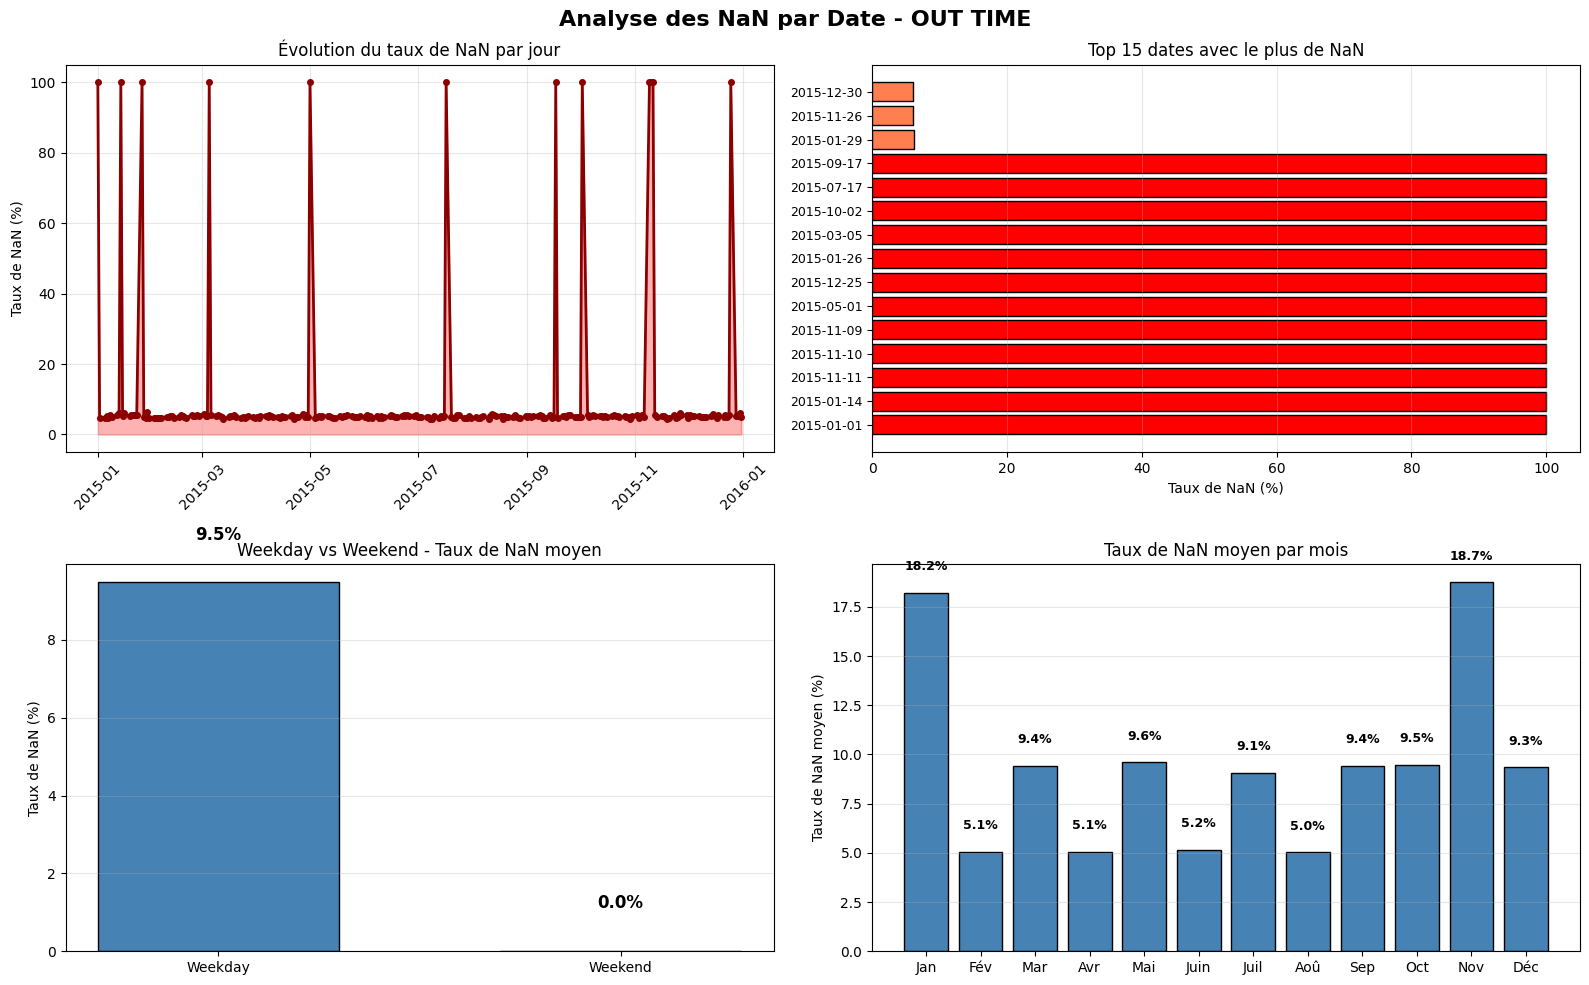


✓ Analyse OUT TIME complétée!


In [8]:
print("\n" + "=" * 80)
print("ANALYSE DES DATES DANS LES NOMS DE COLONNES - OUT TIME")
print("=" * 80)

# 1. EXTRAIRE LES DATES DES NOMS DE COLONNES
print("\n1. EXTRACTION DES DATES:")
print(f"   Dimensions: {data_out_time.shape}")
print(f"   Colonnes (premières): {list(data_out_time.columns[:5])}")

date_columns = data_out_time.columns[1:]
dates = [pd.to_datetime(col, errors='coerce') for col in date_columns]

daily_stats = []
for col, date in zip(date_columns, dates):
    if pd.notna(date):
        nan_count = data_out_time[col].isnull().sum()
        total_values = len(data_out_time)
        nan_rate = (nan_count / total_values * 100) if total_values > 0 else 0
        day_name = date.day_name()
        is_weekend = date.dayofweek >= 5
        month = date.month
        daily_stats.append({
            'Date': date,
            'DayName': day_name,
            'IsWeekend': is_weekend,
            'Month': month,
            'NaN_Count': nan_count,
            'Total_Values': total_values,
            'NaN_Rate_%': nan_rate
        })

daily_df = pd.DataFrame(daily_stats).sort_values('NaN_Rate_%', ascending=False)
print(f"   ✓ {len(daily_df)} dates détectées et analysées")

# TOP 20 DATES AVEC LE PLUS DE NaN
print("\n2. TOP 20 DATES AVEC LE PLUS DE NaN:")
print("-" * 80)
for idx, row in daily_df.head(20).iterrows():
    marker = "🔴" if row['IsWeekend'] else "⚪"
    print(f"   {marker} {row['Date'].strftime('%Y-%m-%d')} ({row['DayName'][:3]}) | "
          f"NaN: {int(row['NaN_Count'])}/{int(row['Total_Values'])} | "
          f"Rate: {row['NaN_Rate_%']:.2f}%")

# JOURS AVEC 100% DE NaN
print("\n3. JOURS AVEC 100% DE NaN:")
full_nan_dates = daily_df[daily_df['NaN_Rate_%'] >= 99.5]
print(f"   Nombre: {len(full_nan_dates)}")
if len(full_nan_dates) > 0:
    for idx, row in full_nan_dates.iterrows():
        marker = "🔴 WEEKEND" if row['IsWeekend'] else "🔴 WEEKDAY"
        print(f"   {marker} | {row['Date'].strftime('%Y-%m-%d')} ({row['DayName']})")

# STATISTIQUES GLOBALES
print("\n4. STATISTIQUES GLOBALES:")
weekday_df = daily_df[daily_df['IsWeekend'] == False]
weekend_df = daily_df[daily_df['IsWeekend'] == True]
weekday_avg = weekday_df['NaN_Rate_%'].mean() if len(weekday_df) > 0 else 0
weekend_avg = weekend_df['NaN_Rate_%'].mean() if len(weekend_df) > 0 else 0

print(f"\n   WEEKDAY (Lun-Ven):")
print(f"      • Nombre de jours: {len(weekday_df)}")
print(f"      • Taux NaN moyen: {weekday_avg:.2f}%")
if len(weekday_df)>0:
    print(f"      • Taux NaN min-max: {weekday_df['NaN_Rate_%'].min():.2f}% - {weekday_df['NaN_Rate_%'].max():.2f}%")

print(f"\n   WEEKEND (Sam-Dim):")
print(f"      • Nombre de jours: {len(weekend_df)}")
print(f"      • Taux NaN moyen: {weekend_avg:.2f}%")
if len(weekend_df)>0:
    print(f"      • Taux NaN min-max: {weekend_df['NaN_Rate_%'].min():.2f}% - {weekend_df['NaN_Rate_%'].max():.2f}%")

# ANALYSE PAR MOIS
print("\n5. ANALYSE PAR MOIS:")
monthly_stats = daily_df.groupby('Month').agg({
    'NaN_Rate_%': 'mean',
    'Date': 'count'
}).rename(columns={'Date': 'Nb_Days'})

months = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
          'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

for month_num, row in monthly_stats.iterrows():
    month_name = months[int(month_num)-1]
    print(f"   {month_name}: {int(row['Nb_Days'])} jours, {row['NaN_Rate_%']:.2f}% NaN moyen")

# VISUALISATIONS (identiques à l'analyse in_time)
print("\n6. CRÉATION DES VISUALISATIONS:")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analyse des NaN par Date - OUT TIME', fontsize=16, fontweight='bold')

# Évolution temporelle
ax = axes[0, 0]
daily_df_sorted = daily_df.sort_values('Date')
ax.plot(daily_df_sorted['Date'], daily_df_sorted['NaN_Rate_%'],
        marker='o', linestyle='-', color='darkred', linewidth=2, markersize=4)
ax.fill_between(daily_df_sorted['Date'], daily_df_sorted['NaN_Rate_%'], alpha=0.3, color='red')
ax.set_title('Évolution du taux de NaN par jour')
ax.set_ylabel('Taux de NaN (%)')
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Top 15
ax = axes[0, 1]
top_15 = daily_df.head(15)
colors_bar = ['red' if x >= 99 else 'orange' if x >= 80 else 'coral' for x in top_15['NaN_Rate_%']]
bars = ax.barh(range(len(top_15)), top_15['NaN_Rate_%'], color=colors_bar, edgecolor='black')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels([d.strftime('%Y-%m-%d') for d in top_15['Date']], fontsize=9)
ax.set_xlabel('Taux de NaN (%)')
ax.set_title('Top 15 dates avec le plus de NaN')
ax.grid(alpha=0.3, axis='x')

# Weekday vs Weekend
ax = axes[1, 0]
categories = ['Weekday', 'Weekend']
rates = [weekday_avg, weekend_avg]
colors = ['steelblue', 'orange']
bars = ax.bar(categories, rates, color=colors, edgecolor='black', width=0.6)
ax.set_ylabel('Taux de NaN (%)')
ax.set_title('Weekday vs Weekend - Taux de NaN moyen')
ax.grid(alpha=0.3, axis='y')
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Par mois
ax = axes[1, 1]
month_names_short = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
month_labels_plot = [month_names_short[m-1] for m in monthly_stats.index]
bars = ax.bar(month_labels_plot, monthly_stats['NaN_Rate_%'], color='steelblue', edgecolor='black')
ax.set_ylabel('Taux de NaN moyen (%)')
ax.set_title('Taux de NaN moyen par mois')
ax.grid(alpha=0.3, axis='y')
for bar, val in zip(bars, monthly_stats['NaN_Rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Analyse OUT TIME complétée!")

In [9]:
def get_daily_stats(df):
    date_cols = df.columns[1:]
    dates = [pd.to_datetime(c, errors='coerce') for c in date_cols]
    stats = []
    total = len(df)
    for col, date in zip(date_cols, dates):
        if pd.notna(date):
            nan_count = df[col].isnull().sum()
            nan_rate = nan_count / total * 100 if total>0 else 0
            stats.append({'Date': date.normalize(), 'NaN_Count': nan_count, 'Total': total, 'NaN_Rate_%': nan_rate})
    return pd.DataFrame(stats).drop_duplicates('Date').set_index('Date').sort_index()

in_stats = get_daily_stats(data_in_time)
out_stats = get_daily_stats(data_out_time)

# Sets by threshold
in_any = set(in_stats.index[in_stats['NaN_Count']>0])
out_any = set(out_stats.index[out_stats['NaN_Count']>0])

in_high = set(in_stats.index[in_stats['NaN_Rate_%']>=50])
out_high = set(out_stats.index[out_stats['NaN_Rate_%']>=50])

in_full = set(in_stats.index[in_stats['NaN_Rate_%']>=99.5])
out_full = set(out_stats.index[out_stats['NaN_Rate_%']>=99.5])

def summarize(a, b, name):
    inter = a & b
    only_a = a - b
    only_b = b - a
    total_union = len(a | b)
    overlap_pct = (len(inter) / total_union * 100) if total_union>0 else 0
    print(f"\n=== {name} ===")
    print(f"  In: {len(a)}  Out: {len(b)}  Intersection: {len(inter)}  Overlap: {overlap_pct:.1f}%")
    if len(inter)>0:
        print("  Exemples (communs):", ", ".join(sorted([d.strftime('%Y-%m-%d') for d in list(inter)[:10]])))
    if len(only_a)>0:
        print("  Exemples (uniques In):", ", ".join(sorted([d.strftime('%Y-%m-%d') for d in list(only_a)[:6]])))
    if len(only_b)>0:
        print("  Exemples (uniques Out):", ", ".join(sorted([d.strftime('%Y-%m-%d') for d in list(only_b)[:6]])))

summarize(in_any, out_any, "Jours avec AU MOINS 1 NaN")
summarize(in_high, out_high, "Jours avec >=50% NaN")
summarize(in_full, out_full, "Jours avec ~100% NaN (>=99.5%)")

# Optionnel: DataFrame récapitulatif pour inspection
combined = pd.DataFrame(index=sorted(set(in_stats.index) | set(out_stats.index)))
combined['in_NaN_%'] = in_stats['NaN_Rate_%']
combined['out_NaN_%'] = out_stats['NaN_Rate_%']
combined = combined.fillna(0)
combined['both_high?'] = (combined['in_NaN_%']>=50) & (combined['out_NaN_%']>=50)
combined.head(20)


=== Jours avec AU MOINS 1 NaN ===
  In: 261  Out: 261  Intersection: 261  Overlap: 100.0%
  Exemples (communs): 2015-01-20, 2015-01-30, 2015-02-25, 2015-04-15, 2015-07-02, 2015-08-05, 2015-11-30, 2015-12-07, 2015-12-23, 2015-12-28

=== Jours avec >=50% NaN ===
  In: 12  Out: 12  Intersection: 12  Overlap: 100.0%
  Exemples (communs): 2015-01-01, 2015-01-14, 2015-01-26, 2015-03-05, 2015-05-01, 2015-07-17, 2015-09-17, 2015-10-02, 2015-11-10, 2015-11-11

=== Jours avec ~100% NaN (>=99.5%) ===
  In: 12  Out: 12  Intersection: 12  Overlap: 100.0%
  Exemples (communs): 2015-01-01, 2015-01-14, 2015-01-26, 2015-03-05, 2015-05-01, 2015-07-17, 2015-09-17, 2015-10-02, 2015-11-10, 2015-11-11


,in_NaN_%,out_NaN_%,both_high?
2015-01-01,100.000000,100.000000,True
2015-01-02,4.739229,4.739229,False
2015-01-05,4.671202,4.671202,False
2015-01-06,5.170068,5.170068,False
2015-01-07,4.739229,4.739229,False
2015-01-08,5.510204,5.510204,False
2015-01-09,4.875283,4.875283,False
2015-01-12,5.419501,5.419501,False
2015-01-13,6.009070,6.009070,False
2015-01-14,100.000000,100.000000,True


In [10]:
import re
import pandas as pd
threshold = 0.90
def drop_sparse_cols(df, thresh=threshold, drop_all_nan=True):
    before = df.shape[1]
    if drop_all_nan:
        df = df.dropna(axis=1, how='all')  # supprime colonnes 100% NaN
    nan_rate = df.isnull().mean()
    to_drop = nan_rate[nan_rate >= thresh].index.tolist()
    to_drop = [c for c in to_drop if c != 'EmployeeID']
    df = df.drop(columns=to_drop)
    after = df.shape[1]
    print(f"Dropped {before-after} columns (kept {after}).")
    if to_drop:
        print("Examples dropped:", to_drop[:20])
    return df

data_in_time = drop_sparse_cols(data_in_time, thresh=threshold)
data_out_time = drop_sparse_cols(data_out_time, thresh=threshold)
# Wide -> long
in_long = data_in_time.melt(id_vars='EmployeeID', var_name='Date', value_name='InTime')
out_long = data_out_time.melt(id_vars='EmployeeID', var_name='Date', value_name='OutTime')
in_long['Date'] = pd.to_datetime(in_long['Date'], errors='coerce')
out_long['Date'] = pd.to_datetime(out_long['Date'], errors='coerce')

# Vectorized parsing: try full datetime parse first
in_dt = pd.to_datetime(in_long['InTime'], errors='coerce', infer_datetime_format=True)
out_dt = pd.to_datetime(out_long['OutTime'], errors='coerce', infer_datetime_format=True)

# For remaining NaT, combine Date + time (vectorized)
mask_in = in_dt.isna() & in_long['InTime'].notna()
if mask_in.any():
    in_dt.loc[mask_in] = pd.to_datetime(
        in_long.loc[mask_in, 'Date'].dt.strftime('%Y-%m-%d') + ' ' + in_long.loc[mask_in, 'InTime'],
        errors='coerce', infer_datetime_format=True)

mask_out = out_dt.isna() & out_long['OutTime'].notna()
if mask_out.any():
    out_dt.loc[mask_out] = pd.to_datetime(
        out_long.loc[mask_out, 'Date'].dt.strftime('%Y-%m-%d') + ' ' + out_long.loc[mask_out, 'OutTime'],
        errors='coerce', infer_datetime_format=True)

in_long['In_dt'] = in_dt
out_long['Out_dt'] = out_dt

# Merge
df = pd.merge(
    in_long[['EmployeeID','Date','InTime','In_dt']],
    out_long[['EmployeeID','Date','OutTime','Out_dt']],
    on=['EmployeeID','Date'],
    how='outer'
)

# Cross-midnight: add 1 day when Out < In
mask = df['In_dt'].notna() & df['Out_dt'].notna() & (df['Out_dt'] < df['In_dt'])
df.loc[mask, 'Out_dt'] = df.loc[mask, 'Out_dt'] + pd.Timedelta(days=1)

# Duration in hours
df['Duration'] = df['Out_dt'] - df['In_dt']
df['Hours'] = df['Duration'].dt.total_seconds() / 3600.0
df['OvertimeHours'] = (df['Hours'] - 9).clip(lower=0)
# Quick checks
print("Rows:", len(df))
print(df[['EmployeeID','Date','InTime','OutTime','In_dt','Out_dt','Hours']].head())
print(df['Hours'].describe())# Seuil à ajuster (ex: 0.90 = supprimer colonnes ≥90% NaN)
print(df['OvertimeHours'].describe())# Seuil à ajuster (ex: 0.90 = supprimer colonnes ≥90% NaN)



Dropped 12 columns (kept 250).
Dropped 12 columns (kept 250).


C:\Users\Natha\AppData\Local\Temp\ipykernel_69344\3732640525.py:27: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  in_dt = pd.to_datetime(in_long['InTime'], errors='coerce', infer_datetime_format=True)
C:\Users\Natha\AppData\Local\Temp\ipykernel_69344\3732640525.py:28: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  out_dt = pd.to_datetime(out_long['OutTime'], errors='coerce', infer_datetime_format=True)


Rows: 1098090
   EmployeeID       Date               InTime              OutTime  \
0           1 2015-01-02  2015-01-02 09:43:45  2015-01-02 16:56:15   
1           1 2015-01-05  2015-01-05 10:08:48  2015-01-05 17:20:11   
2           1 2015-01-06  2015-01-06 09:54:26  2015-01-06 17:19:05   
3           1 2015-01-07  2015-01-07 09:34:31  2015-01-07 16:34:55   
4           1 2015-01-08  2015-01-08 09:51:09  2015-01-08 17:08:32   

                In_dt              Out_dt     Hours  
0 2015-01-02 09:43:45 2015-01-02 16:56:15  7.208333  
1 2015-01-05 10:08:48 2015-01-05 17:20:11  7.189722  
2 2015-01-06 09:54:26 2015-01-06 17:19:05  7.410833  
3 2015-01-07 09:34:31 2015-01-07 16:34:55  7.006667  
4 2015-01-08 09:51:09 2015-01-08 17:08:32  7.289722  
count    1.041930e+06
mean     7.708607e+00
std      1.376132e+00
min      4.726944e+00
25%      6.662222e+00
50%      7.420278e+00
75%      8.397500e+00
max      1.208861e+01
Name: Hours, dtype: float64
count    1.041930e+06
mean     2.0109

In [ ]:
print(df.head())

In [11]:

# 1) Inspect# 1) Stats par employé (sans merge)
emp_stats = df.groupby('EmployeeID').agg(
    AvgWorkingHours=('Hours', 'mean'),
    StdWorkingHours=('Hours', 'std'),
    TotalHours=('Hours', 'sum'),
    DaysWorked=('Hours', 'count'),
    OvertimeDays=('Hours', lambda x: (x > 8).sum()),
    TotalOvertimeHours=('OvertimeHours', 'sum')   # <-- ajouté
).reset_index()


emp_stats['AvgOvertimePerDay'] = emp_stats['TotalOvertimeHours'] / emp_stats['DaysWorked']
print(emp_stats.head())





   EmployeeID  AvgWorkingHours  StdWorkingHours   TotalHours  DaysWorked  \
0           1         7.373651         0.283224  1710.686944         232   
1           2         7.718969         0.313351  1821.676667         236   
2           3         7.013240         0.311551  1697.204167         242   
3           4         7.193678         0.284133  1690.514444         235   
4           5         8.006175         0.300656  1961.512778         245   

   OvertimeDays  TotalOvertimeHours  AvgOvertimePerDay  
0             0                 0.0                0.0  
1            42                 0.0                0.0  
2             0                 0.0                0.0  
3             0                 0.0                0.0  
4           115                 0.0                0.0  


In [12]:
emp_stats.to_csv('../Output/employee_hours_stats.csv', index=False)
print("Columns:", df.columns.tolist())
print(df.head())

Columns: ['EmployeeID', 'Date', 'InTime', 'In_dt', 'OutTime', 'Out_dt', 'Duration', 'Hours', 'OvertimeHours']
   EmployeeID       Date               InTime               In_dt  \
0           1 2015-01-02  2015-01-02 09:43:45 2015-01-02 09:43:45   
1           1 2015-01-05  2015-01-05 10:08:48 2015-01-05 10:08:48   
2           1 2015-01-06  2015-01-06 09:54:26 2015-01-06 09:54:26   
3           1 2015-01-07  2015-01-07 09:34:31 2015-01-07 09:34:31   
4           1 2015-01-08  2015-01-08 09:51:09 2015-01-08 09:51:09   

               OutTime              Out_dt        Duration     Hours  \
0  2015-01-02 16:56:15 2015-01-02 16:56:15 0 days 07:12:30  7.208333   
1  2015-01-05 17:20:11 2015-01-05 17:20:11 0 days 07:11:23  7.189722   
2  2015-01-06 17:19:05 2015-01-06 17:19:05 0 days 07:24:39  7.410833   
3  2015-01-07 16:34:55 2015-01-07 16:34:55 0 days 07:00:24  7.006667   
4  2015-01-08 17:08:32 2015-01-08 17:08:32 0 days 07:17:23  7.289722   

   OvertimeHours  
0            0.0  
1   

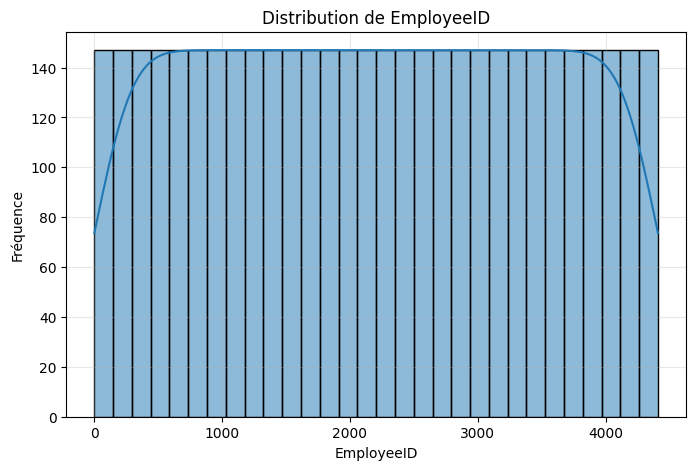

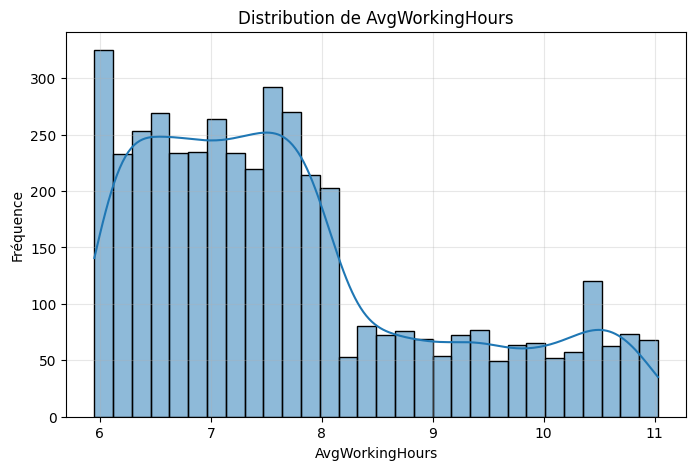

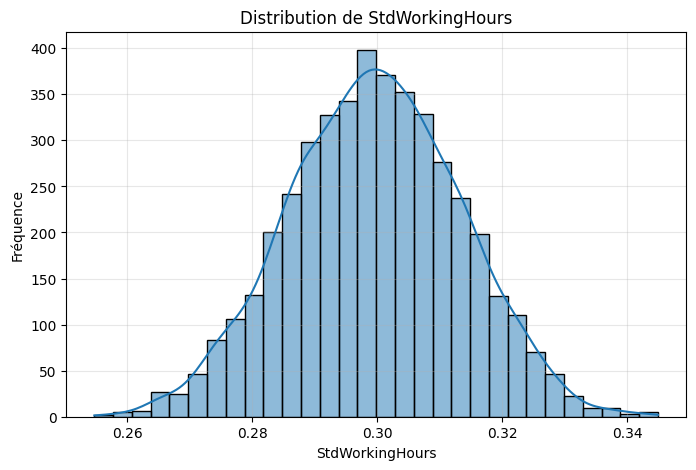

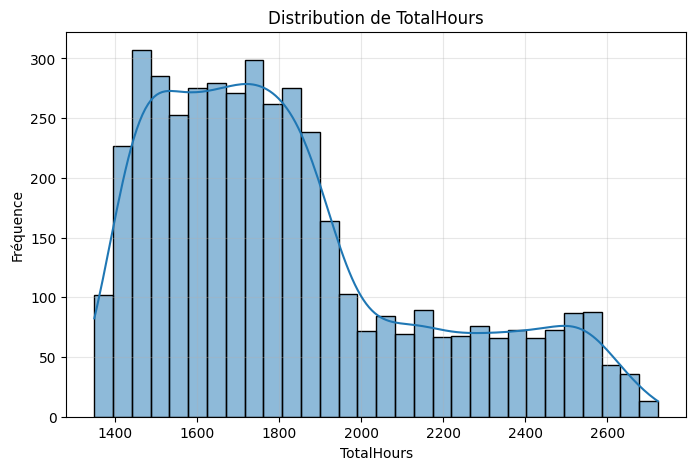

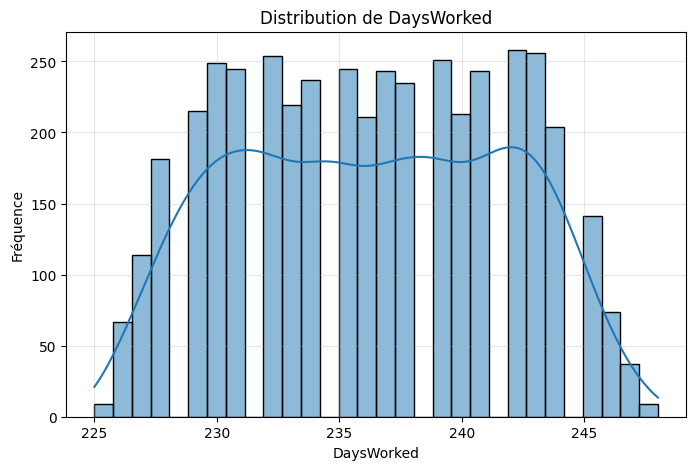

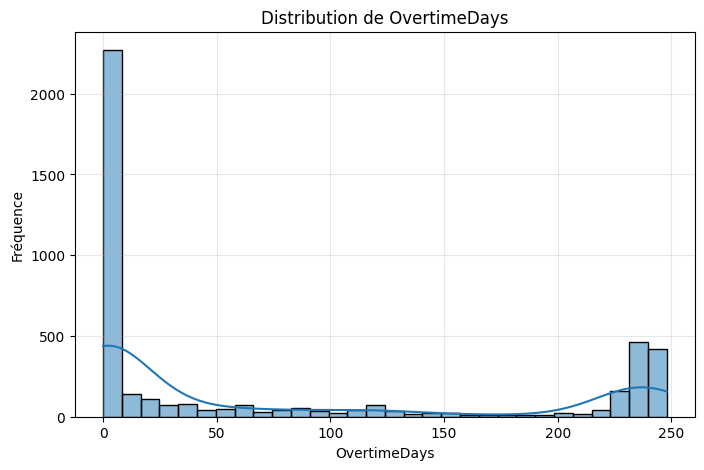

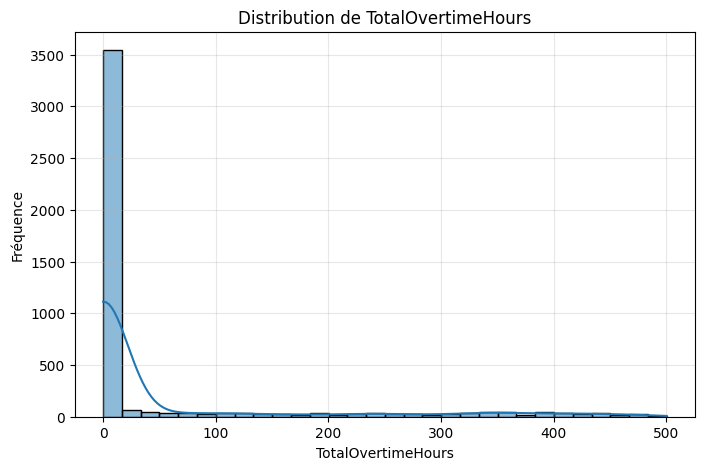

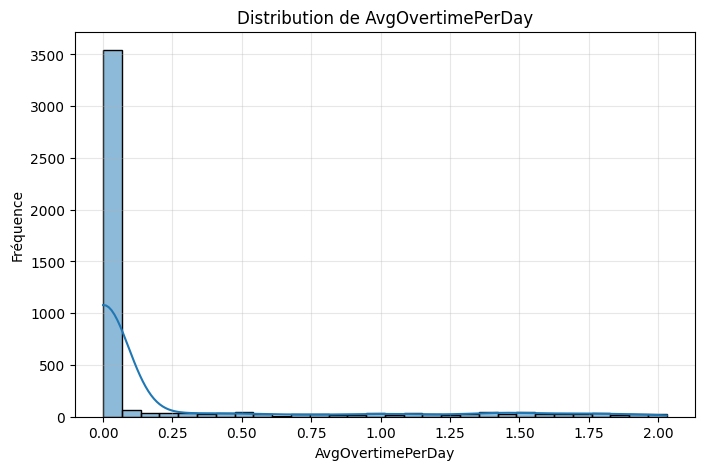

In [13]:
# Tracer histogramme de chaque colonne
for col in emp_stats.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(emp_stats[col].dropna(), bins=30, kde=True)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    plt.grid(alpha=0.3)
    plt.show()


## 5. Visualisations des États des Heures de Travail
Analyse des heures d'arrivée, de départ, et des jours non travaillés



1. DISTRIBUTION DES HEURES D'ARRIVÉE (InTime)
Total heures d'arrivée valides: 1041930
Missing InTime: 56160

Statistiques des heures d'arrivée:
count    1.041930e+06
mean     9.991772e+00
std      2.778743e-01
min      8.600000e+00
25%      9.800000e+00
50%      1.000000e+01
75%      1.018333e+01
max      1.131667e+01
Name: In_Hour, dtype: float64


C:\Users\Natha\AppData\Local\Temp\ipykernel_69344\2569472135.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_day, labels=day_fr, patch_artist=True)


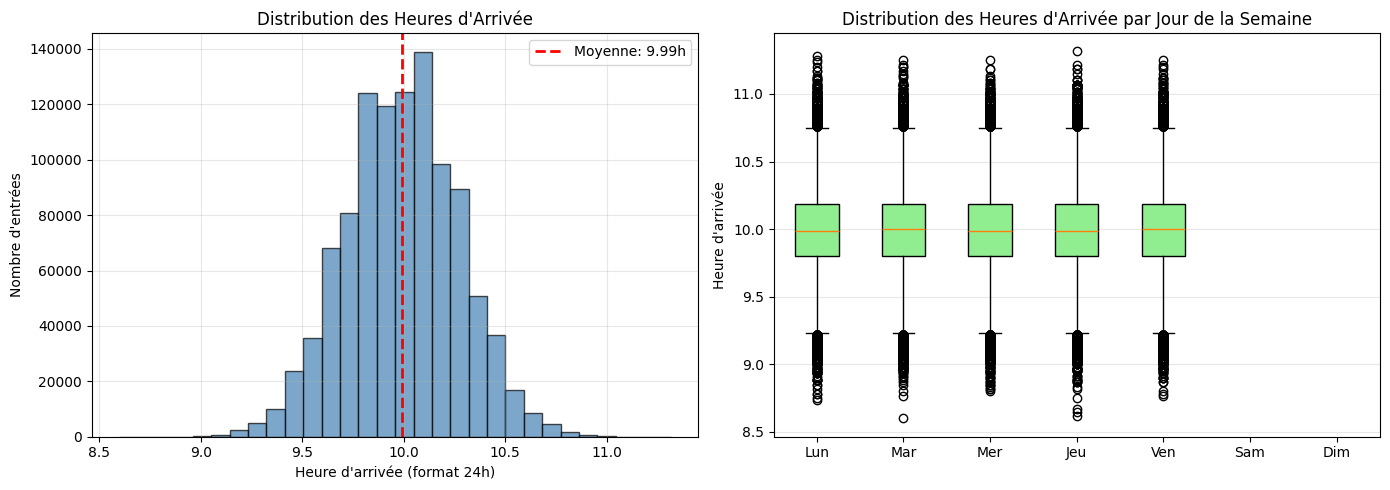

In [14]:
print("\n" + "=" * 80)
print("1. DISTRIBUTION DES HEURES D'ARRIVÉE (InTime)")
print("=" * 80)

# Extraire heures et minutes des InTime valides
valid_in = df[df['In_dt'].notna()].copy()
valid_in['In_Hour'] = valid_in['In_dt'].dt.hour + valid_in['In_dt'].dt.minute / 60

print(f"Total heures d'arrivée valides: {len(valid_in)}")
print(f"Missing InTime: {df['In_dt'].isna().sum()}")
print(f"\nStatistiques des heures d'arrivée:")
print(valid_in['In_Hour'].describe())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des heures
ax = axes[0]
ax.hist(valid_in['In_Hour'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Heure d\'arrivée (format 24h)')
ax.set_ylabel('Nombre d\'entrées')
ax.set_title('Distribution des Heures d\'Arrivée')
ax.grid(alpha=0.3)
ax.axvline(valid_in['In_Hour'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne: {valid_in['In_Hour'].mean():.2f}h")
ax.legend()

# Box plot par jour de semaine
ax = axes[1]
valid_in['DayOfWeek'] = valid_in['In_dt'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_fr = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

data_by_day = [valid_in[valid_in['DayOfWeek'] == day]['In_Hour'].values for day in day_order]
bp = ax.boxplot(data_by_day, labels=day_fr, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
ax.set_ylabel('Heure d\'arrivée')
ax.set_title('Distribution des Heures d\'Arrivée par Jour de la Semaine')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



2. DISTRIBUTION DES HEURES DE DÉPART (OutTime)
Total heures de départ valides: 1041930
Missing OutTime: 56160

Statistiques des heures de départ:
count    1.041930e+06
mean     1.770037e+01
std      1.404039e+00
min      1.433333e+01
25%      1.665000e+01
50%      1.741667e+01
75%      1.843333e+01
max      2.256667e+01
Name: Out_Hour, dtype: float64


C:\Users\Natha\AppData\Local\Temp\ipykernel_69344\328093944.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_day, labels=day_fr, patch_artist=True)


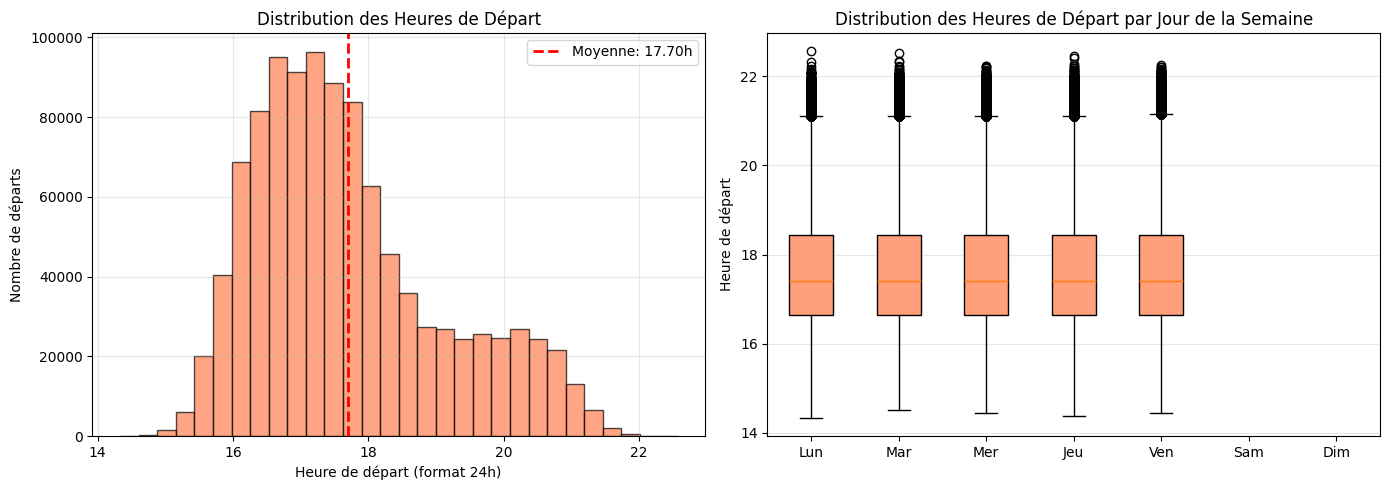

In [15]:
print("\n" + "=" * 80)
print("2. DISTRIBUTION DES HEURES DE DÉPART (OutTime)")
print("=" * 80)

# Extraire heures et minutes des OutTime valides
valid_out = df[df['Out_dt'].notna()].copy()
valid_out['Out_Hour'] = valid_out['Out_dt'].dt.hour + valid_out['Out_dt'].dt.minute / 60

print(f"Total heures de départ valides: {len(valid_out)}")
print(f"Missing OutTime: {df['Out_dt'].isna().sum()}")
print(f"\nStatistiques des heures de départ:")
print(valid_out['Out_Hour'].describe())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des heures
ax = axes[0]
ax.hist(valid_out['Out_Hour'], bins=30, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Heure de départ (format 24h)')
ax.set_ylabel('Nombre de départs')
ax.set_title('Distribution des Heures de Départ')
ax.grid(alpha=0.3)
ax.axvline(valid_out['Out_Hour'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne: {valid_out['Out_Hour'].mean():.2f}h")
ax.legend()

# Box plot par jour de semaine
ax = axes[1]
valid_out['DayOfWeek'] = valid_out['Out_dt'].dt.day_name()
data_by_day = [valid_out[valid_out['DayOfWeek'] == day]['Out_Hour'].values for day in day_order]
bp = ax.boxplot(data_by_day, labels=day_fr, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightsalmon')
ax.set_ylabel('Heure de départ')
ax.set_title('Distribution des Heures de Départ par Jour de la Semaine')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



3. DISTRIBUTION DES HEURES TRAVAILLÉES PAR JOUR
Total jours travaillés: 1041930
Total jours NON travaillés (missing): 56160
Taux de jours travaillés: 94.89%

Statistiques des heures travaillées:
count    1.041930e+06
mean     7.708607e+00
std      1.376132e+00
min      4.726944e+00
25%      6.662222e+00
50%      7.420278e+00
75%      8.397500e+00
max      1.208861e+01
Name: Hours, dtype: float64


C:\Users\Natha\AppData\Local\Temp\ipykernel_69344\3598241496.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_day_hours, labels=day_fr, patch_artist=True)


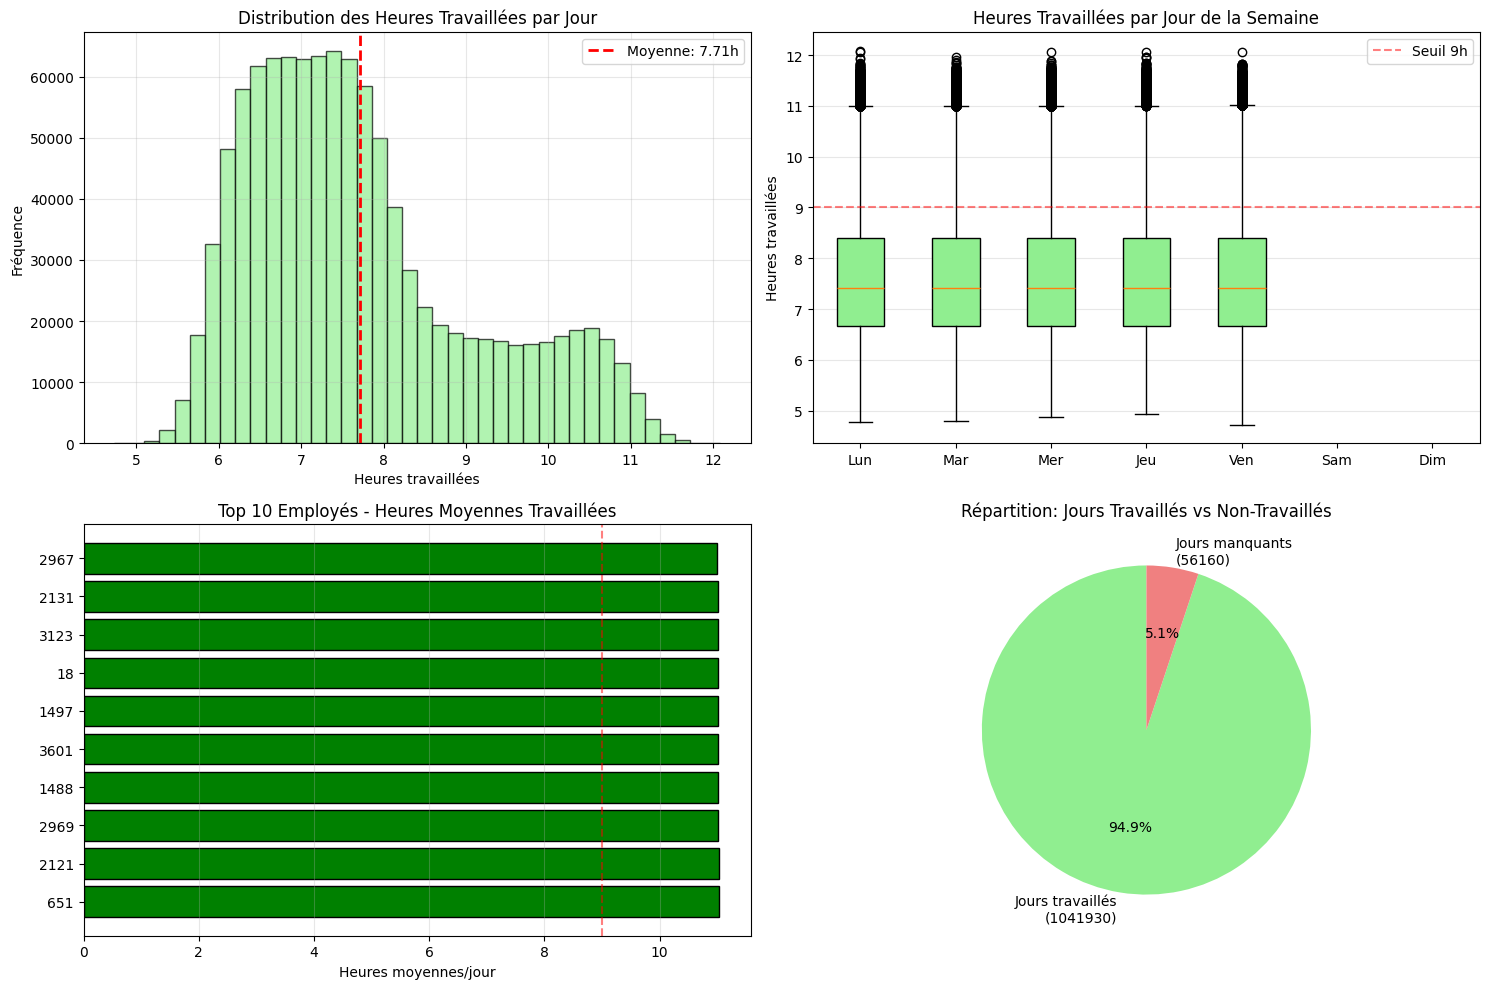

In [16]:
print("\n" + "=" * 80)
print("3. DISTRIBUTION DES HEURES TRAVAILLÉES PAR JOUR")
print("=" * 80)

# Heures valides
valid_hours = df[df['Hours'].notna()].copy()
print(f"Total jours travaillés: {len(valid_hours)}")
print(f"Total jours NON travaillés (missing): {len(df) - len(valid_hours)}")
print(f"Taux de jours travaillés: {len(valid_hours) / len(df) * 100:.2f}%")
print(f"\nStatistiques des heures travaillées:")
print(valid_hours['Hours'].describe())

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme global
ax = axes[0, 0]
ax.hist(valid_hours['Hours'], bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
ax.set_xlabel('Heures travaillées')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des Heures Travaillées par Jour')
ax.axvline(valid_hours['Hours'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne: {valid_hours['Hours'].mean():.2f}h")
ax.legend()
ax.grid(alpha=0.3)

# Distribution par jour de semaine
ax = axes[0, 1]
valid_hours['DayOfWeek'] = valid_hours['Date'].dt.day_name()
data_by_day_hours = [valid_hours[valid_hours['DayOfWeek'] == day]['Hours'].values for day in day_order]
bp = ax.boxplot(data_by_day_hours, labels=day_fr, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
ax.set_ylabel('Heures travaillées')
ax.set_title('Heures Travaillées par Jour de la Semaine')
ax.grid(alpha=0.3, axis='y')
ax.axhline(9, color='red', linestyle='--', alpha=0.5, label='Seuil 9h')
ax.legend()

# Top 10 employés - heures moyennes
ax = axes[1, 0]
emp_hours_avg = valid_hours.groupby('EmployeeID')['Hours'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)
colors_emp = ['green' if x >= 9 else 'orange' if x >= 8 else 'red' for x in emp_hours_avg['mean']]
bars = ax.barh(range(len(emp_hours_avg)), emp_hours_avg['mean'], color=colors_emp, edgecolor='black')
ax.set_yticks(range(len(emp_hours_avg)))
ax.set_yticklabels(emp_hours_avg.index)
ax.set_xlabel('Heures moyennes/jour')
ax.set_title('Top 10 Employés - Heures Moyennes Travaillées')
ax.axvline(9, color='red', linestyle='--', alpha=0.5)
ax.grid(alpha=0.3, axis='x')

# Pie chart: Jours travaillés vs non-travaillés
ax = axes[1, 1]
worked_days = len(valid_hours)
missing_days = len(df) - len(valid_hours)
sizes = [worked_days, missing_days]
labels = [f'Jours travaillés\n({worked_days})', f'Jours manquants\n({missing_days})']
colors_pie = ['lightgreen', 'lightcoral']
ax.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
ax.set_title('Répartition: Jours Travaillés vs Non-Travaillés')

plt.tight_layout()
plt.show()



4. ANALYSE DES JOURS MANQUANTS PAR EMPLOYÉ

Total employés: 4410

Employés avec le plus de jours manquants:
 EmployeeID  Total_Days  Worked_Days  Missing_Days  Missing_Rate_%
       3007         225          225            24           10.67
       2359         225          225            24           10.67
       2268         225          225            24           10.67
       2881         225          225            24           10.67
       1759         225          225            24           10.67
       2178         225          225            24           10.67
       1552         225          225            24           10.67
       2071         225          225            24           10.67
        741         225          225            24           10.67
       1036         226          226            23           10.18
       4060         226          226            23           10.18
       2990         226          226            23           10.18
       3738         

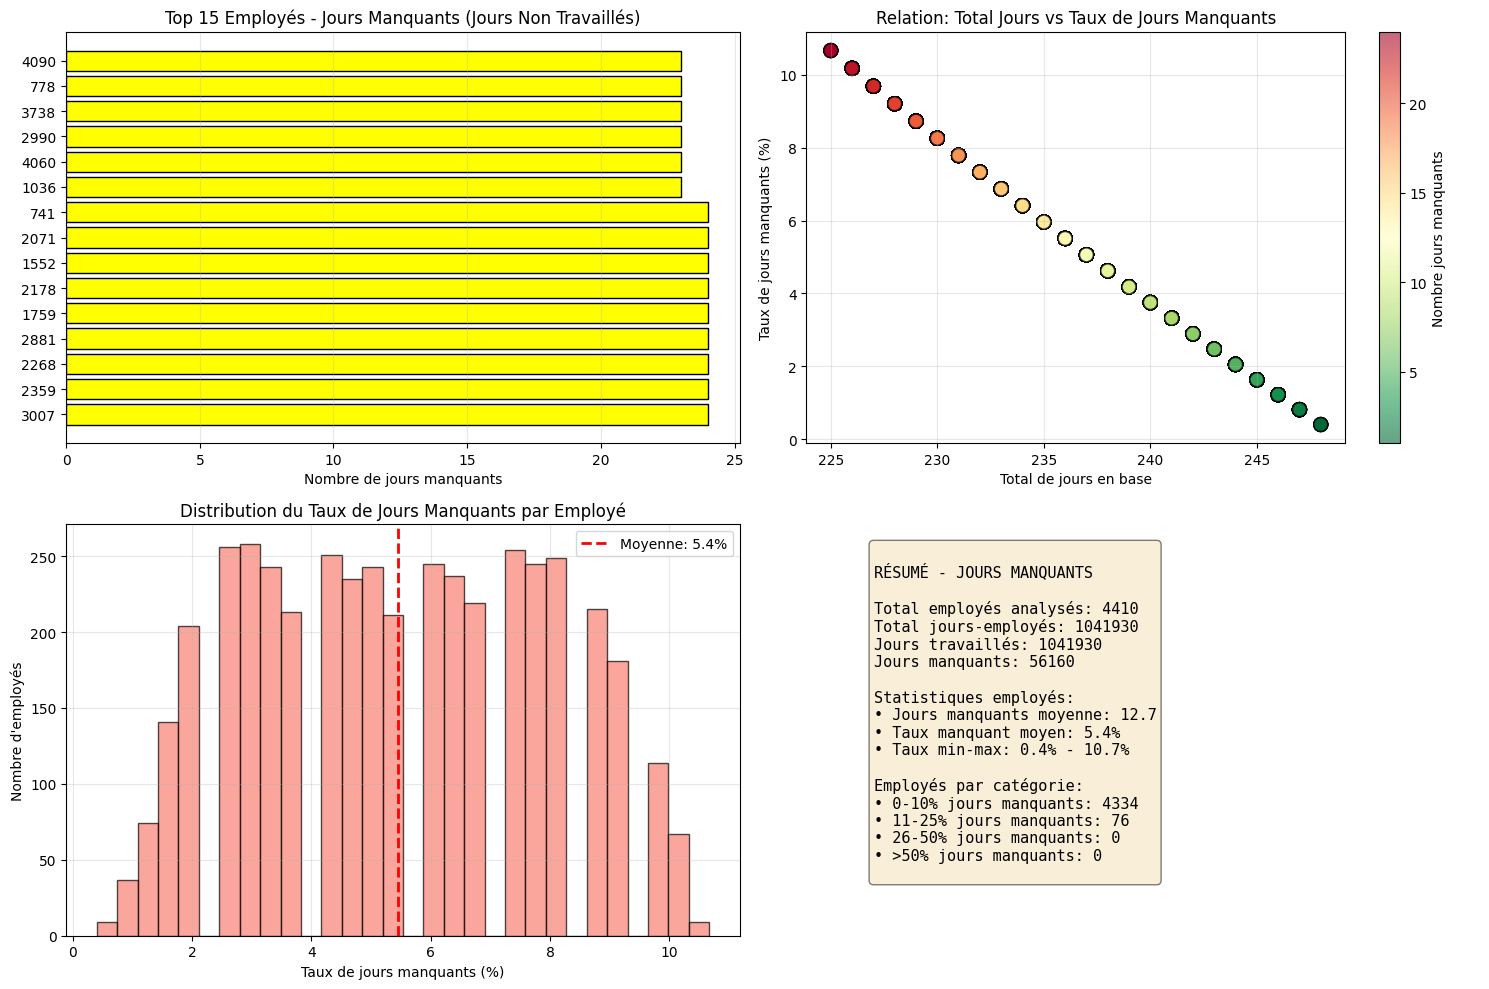


✓ Analyse des jours manquants complétée!


In [17]:
print("\n" + "=" * 80)
print("4. ANALYSE DES JOURS MANQUANTS PAR EMPLOYÉ")
print("=" * 80)

# Compter les jours travaillés et manquants par employé
emp_days = df.groupby('EmployeeID').agg({
    'Hours': ['count', lambda x: x.notna().sum(), lambda x: x.isna().sum()]
}).reset_index()

emp_days.columns = ['EmployeeID', 'Total_Days', 'Worked_Days', 'Missing_Days']
emp_days['Missing_Rate_%'] = (emp_days['Missing_Days'] / emp_days['Total_Days'] * 100).round(2)
emp_days = emp_days.sort_values('Missing_Days', ascending=False)

print(f"\nTotal employés: {len(emp_days)}")
print(f"\nEmployés avec le plus de jours manquants:")
print(emp_days.head(15).to_string(index=False))

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top 15 employés - jours manquants
ax = axes[0, 0]
top_missing = emp_days.head(15)
colors_missing = ['red' if x > 50 else 'orange' if x > 25 else 'yellow' for x in top_missing['Missing_Rate_%']]
bars = ax.barh(range(len(top_missing)), top_missing['Missing_Days'], color=colors_missing, edgecolor='black')
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing['EmployeeID'])
ax.set_xlabel('Nombre de jours manquants')
ax.set_title('Top 15 Employés - Jours Manquants (Jours Non Travaillés)')
ax.grid(alpha=0.3, axis='x')

# Scatter: Total days vs Missing rate
ax = axes[0, 1]
scatter = ax.scatter(emp_days['Total_Days'], emp_days['Missing_Rate_%'], 
                     s=100, alpha=0.6, c=emp_days['Missing_Days'], cmap='RdYlGn_r', edgecolor='black')
ax.set_xlabel('Total de jours en base')
ax.set_ylabel('Taux de jours manquants (%)')
ax.set_title('Relation: Total Jours vs Taux de Jours Manquants')
ax.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Nombre jours manquants')

# Distribution du taux de jours manquants
ax = axes[1, 0]
ax.hist(emp_days['Missing_Rate_%'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
ax.set_xlabel('Taux de jours manquants (%)')
ax.set_ylabel('Nombre d\'employés')
ax.set_title('Distribution du Taux de Jours Manquants par Employé')
ax.axvline(emp_days['Missing_Rate_%'].mean(), color='red', linestyle='--', linewidth=2, 
          label=f"Moyenne: {emp_days['Missing_Rate_%'].mean():.1f}%")
ax.legend()
ax.grid(alpha=0.3)

# Résumé statistique
ax = axes[1, 1]
ax.axis('off')

summary_text = f"""
RÉSUMÉ - JOURS MANQUANTS

Total employés analysés: {len(emp_days)}
Total jours-employés: {emp_days['Total_Days'].sum()}
Jours travaillés: {emp_days['Worked_Days'].sum()}
Jours manquants: {emp_days['Missing_Days'].sum()}

Statistiques employés:
• Jours manquants moyenne: {emp_days['Missing_Days'].mean():.1f}
• Taux manquant moyen: {emp_days['Missing_Rate_%'].mean():.1f}%
• Taux min-max: {emp_days['Missing_Rate_%'].min():.1f}% - {emp_days['Missing_Rate_%'].max():.1f}%

Employés par catégorie:
• 0-10% jours manquants: {len(emp_days[emp_days['Missing_Rate_%'] <= 10])}
• 11-25% jours manquants: {len(emp_days[(emp_days['Missing_Rate_%'] > 10) & (emp_days['Missing_Rate_%'] <= 25)])}
• 26-50% jours manquants: {len(emp_days[(emp_days['Missing_Rate_%'] > 25) & (emp_days['Missing_Rate_%'] <= 50)])}
• >50% jours manquants: {len(emp_days[emp_days['Missing_Rate_%'] > 50])}
"""

ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✓ Analyse des jours manquants complétée!")
